# ESMM + MMoE 全面指南：Experiment × torchkeras × 原生 PyTorch

本 Notebook 使用合成转化链路，完整演示初始化、数据处理、两条训练路径、TensorBoard、实验比较、配置派生与恢复推理。
模型和 loss 是普通 PyTorch 组件；训练可使用 torchkeras，也可完全由你自己编写。

配套：[文字指南](esmm_mmoe_complete_guide.md) · [可执行脚本](esmm_mmoe_experiment.py)。
使用本项目 `.venv` 内核，**Restart & Run All**。默认 CPU、2400 行、6 epochs；每次执行创建新 Run。

## 1. 安装与架构

仓库根目录执行：
```bash
uv sync --extra torchkeras --extra tensorboard --extra hydra --group dev
# 同时保留全部已有可选后端：uv sync --all-extras --group dev
```
原生路径只需 `pytorch` extra；TensorBoard 独立可选。

`models/esmm_mmoe` 定义模型 → `training/torchkeras` 可选训练适配 → `experiment` 管理配置和结果。
初始化不导入训练后端；模型也不依赖 Experiment。

In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/phl_risk").is_dir())
sys.path.insert(0, str(REPO / "src"))

In [2]:
import hashlib
import random
import zipfile
from copy import deepcopy
from importlib.metadata import version
from pathlib import Path
from tempfile import TemporaryDirectory

import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from phl_risk.modeling.experiment import Experiment
from phl_risk.modeling.experiment.adapters.pytorch import load_pytorch, record_pytorch
from phl_risk.modeling.experiment.configuration import read_yaml_config
from phl_risk.modeling.models.esmm_mmoe import ESMMLoss, ESMMMoE
from phl_risk.modeling.training.esmm import evaluate_esmm

print("PyTorch:", version("torch"))
print("torchkeras:", version("torchkeras"))
print("TensorBoard:", version("tensorboard"))

PyTorch: 2.14.0
torchkeras: 3.9.9
TensorBoard: 2.20.0


## 2. 概率关系与合成数据

`ctr=P(C|x)`，`cvr=P(V|C,x)`，`ctcvr=ctr*cvr`。
监督目标是全空间 `y_ctr`、`y_ctcvr`，必须满足 `y_ctcvr <= y_ctr`。
合成数据包含连续特征、分类特征以及少量缺失值，没有私有业务数据。

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_data(rows=2400, seed=2026):
    """Generate an actual conversion chain, then introduce missing features."""
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(rows, 6))
    channel = rng.choice(["search", "feed", "direct"], size=rows)
    device = rng.choice(["mobile", "desktop"], size=rows)

    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    ctr = sigmoid(0.8 * x[:, 0] - 0.6 * x[:, 1] + 0.5 * (channel == "search"))
    cvr = sigmoid(-0.7 + 0.9 * x[:, 2] + 0.6 * x[:, 0] - 0.3 * (device == "mobile"))
    y_ctr = rng.binomial(1, ctr)
    y_ctcvr = y_ctr * rng.binomial(1, cvr)
    frame = pd.DataFrame(x, columns=[f"x{i}" for i in range(6)])
    frame["channel"], frame["device"] = channel, device
    frame["y_ctr"], frame["y_ctcvr"] = y_ctr, y_ctcvr
    frame.loc[rng.random(rows) < 0.03, "x0"] = np.nan
    frame.loc[rng.random(rows) < 0.02, "channel"] = None
    assert (frame.y_ctcvr <= frame.y_ctr).all()
    return frame


def split_data(frame, seed=2026):
    """Stratify the three valid chain outcomes; split BEFORE fitting preprocessing."""
    chain = frame.y_ctr + frame.y_ctcvr
    train, rest = train_test_split(frame, test_size=0.4, random_state=seed, stratify=chain)
    valid, test = train_test_split(
        rest, test_size=0.5, random_state=seed, stratify=rest.y_ctr + rest.y_ctcvr
    )
    return {"train": train.copy(), "valid": valid.copy(), "test": test.copy()}

In [4]:
SEED = 2026
seed_everything(SEED)
raw = make_data(2400, SEED)
partitions = split_data(raw, SEED)
summary = pd.DataFrame(
    {
        name: {"rows": len(df), "ctr_rate": df.y_ctr.mean(), "ctcvr_rate": df.y_ctcvr.mean()}
        for name, df in partitions.items()
    }
).T
display(summary)
assert not set(partitions["train"].index) & set(partitions["test"].index)

,rows,ctr_rate,ctcvr_rate
train,1440.0,0.513194,0.194444
valid,480.0,0.512500,0.193750
test,480.0,0.512500,0.193750


## 3. 先切分，再拟合预处理

仅 train 学习中位数、标准化统计与类别词表。未知/缺失类别使用 ID 0。
保存普通 dict 与 sklearn 对象，恢复时不依赖 Notebook 中的自定义类。真实业务可以替换为已有 DataPrep。

In [5]:
def fit_preprocessor(train, continuous, categorical):
    """Example-only preprocessing, fitted solely on the training partition.

    ID 0 represents missing/unseen categories. Artifacts contain a plain dictionary
    and sklearn objects, so loading does not depend on a class defined in __main__.
    """
    pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]
    )
    pipeline.fit(train[continuous])
    vocabularies = {
        column: {
            value: i + 1
            for i, value in enumerate(sorted(train[column].dropna().astype(str).unique()))
        }
        for column in categorical
    }
    return {
        "continuous_features": list(continuous),
        "categorical_features": list(categorical),
        "continuous_pipeline": pipeline,
        "vocabularies": vocabularies,
        "unknown_category_id": 0,
    }


def transform_features(frame, state):
    columns = state["continuous_features"] + state["categorical_features"]
    missing = set(columns) - set(frame.columns)
    if missing:
        raise ValueError(f"Missing feature columns: {sorted(missing)}")
    continuous = (
        state["continuous_pipeline"]
        .transform(frame[state["continuous_features"]])
        .astype(np.float32)
    )
    categorical = np.empty((len(frame), len(state["categorical_features"])), dtype=np.int64)
    for i, column in enumerate(state["categorical_features"]):
        vocabulary = state["vocabularies"][column]
        categorical[:, i] = [
            vocabulary.get(str(value), 0) if pd.notna(value) else 0 for value in frame[column]
        ]
    return categorical, continuous

In [6]:
continuous = [f"x{i}" for i in range(6)]
categorical = ["channel", "device"]
state = fit_preprocessor(partitions["train"], continuous, categorical)
x_cat, x_cont = transform_features(partitions["valid"], state)
print("分类输入:", x_cat.shape, x_cat.dtype, "连续输入:", x_cont.shape, x_cont.dtype)
display(
    pd.DataFrame(
        {
            "feature": categorical,
            "cardinality_including_unknown": [
                len(state["vocabularies"][c]) + 1 for c in categorical
            ],
        }
    )
)

分类输入: (480, 2) int64 连续输入: (480, 6) float32


,feature,cardinality_including_unknown
0,channel,4
1,device,3


## 4. 初始化 ESMM 方法空间与 baseline

`initialize(method="esmm_mmoe")` 生成模型专属配置。已有 baseline 不会覆盖。
`num_continuous: null` 表示需要从 schema 确定维数；在 start_run 前解析完整配置。

In [7]:
exp = Experiment(root=REPO / "experiments/esmm_mmoe_notebook")
space = exp.initialize(method="esmm_mmoe", comparison_partitions=["valid", "test"])
cfg = read_yaml_config(space.config_dir / "baseline.yaml")
cfg["model"].update(
    num_continuous=len(continuous),
    categorical_cardinalities=[len(state["vocabularies"][c]) + 1 for c in categorical],
    share_dim=24,
    base_dim=12,
    expert_units=8,
)
cfg["data"].update(continuous_features=continuous, categorical_features=categorical, batch_size=64)
cfg["train"].update(epochs=6, seed=SEED, patience=3)
cfg["scheduler"].update(step_size=2)
print("Baseline:", space.config_dir / "baseline.yaml")
display(cfg)

Baseline: /Users/xuetao/git_code/phi_risk/experiments/esmm_mmoe_notebook/esmm_mmoe/configs/baseline.yaml


{'model': {'num_continuous': 6,
  'categorical_cardinalities': [4, 3],
  'embedding_dim': 4,
  'share_dim': 24,
  'base_dim': 12,
  'expert_units': 8,
  'num_experts': 4,
  'dropout': 0.1,
  'batch_norm': False,
  'normalize_shared': False,
  'use_expert_bias': True,
  'use_gate_bias': True,
  'expert_activation': 'elu'},
 'loss': {'ctr_weight': 1.0, 'ctcvr_weight': 1.0},
 'optimizer': {'name': 'Adam', 'lr': 0.001, 'weight_decay': 0.0},
 'scheduler': {'name': 'StepLR',
  'step_size': 2,
  'gamma': 0.5,
  'interval': 'epoch'},
 'data': {'continuous_features': ['x0', 'x1', 'x2', 'x3', 'x4', 'x5'],
  'categorical_features': ['channel', 'device'],
  'labels': {'ctr': 'y_ctr', 'ctcvr': 'y_ctcvr'},
  'batch_size': 64,
  'num_workers': 0,
  'drop_last': False},
 'train': {'epochs': 6,
  'seed': 2026,
  'monitor': 'val_loss',
  'mode': 'min',
  'patience': 3,
  'max_grad_norm': 1.0},
 'torchkeras': {'plot': False,
  'quiet': True,
  'cpu': True,
  'mixed_precision': 'no',
  'gradient_accumulat

## 5. 独立使用网络与损失

网络输出命名概率，loss 由两项 BCE 加权组成。没有训练器或 Experiment 也能使用。
纯连续特征可传 `categorical_cardinalities=[]` 和空 `int64[N,0]`。

In [8]:
net = ESMMMoE(**cfg["model"])
loss_fn = ESMMLoss(**cfg["loss"])
cat = torch.from_numpy(x_cat[:8])
cont = torch.from_numpy(x_cont[:8])
out = net(cat, cont)
labels = {
    "ctr": torch.tensor(partitions["valid"].y_ctr.iloc[:8].to_numpy()),
    "ctcvr": torch.tensor(partitions["valid"].y_ctcvr.iloc[:8].to_numpy()),
}
parts = loss_fn.components(out, labels)
parts["loss"].backward()
torch.testing.assert_close(out["ctcvr"], out["ctr"] * out["cvr"])
print({k: tuple(v.shape) for k, v in out.items()})
print({k: v.item() for k, v in parts.items()})

{'ctr': (8, 1), 'cvr': (8, 1), 'ctcvr': (8, 1)}
{'loss': 1.1389415264129639, 'ctr_loss': 0.7196688055992126, 'ctcvr_loss': 0.41927266120910645}


## 6. DataLoader、优化器与学习率策略

batch 为 `(x_cat, x_cont, y_ctr, y_ctcvr)`。两条训练路径共享此合同。
训练可以 shuffle；完整评估不 drop_last。默认 StepLR 每个 epoch 更新一次。
启用 BatchNorm 时，需避免训练的单样本 batch。

In [9]:
def make_loaders(partitions, state, cfg):
    datasets = {}
    labels = cfg["data"]["labels"]
    for name, frame in partitions.items():
        cat, cont = transform_features(frame, state)
        datasets[name] = TensorDataset(
            torch.from_numpy(cat),
            torch.from_numpy(cont),
            torch.tensor(frame[labels["ctr"]].to_numpy(), dtype=torch.float32),
            torch.tensor(frame[labels["ctcvr"]].to_numpy(), dtype=torch.float32),
        )
    loader_args = {
        "batch_size": cfg["data"]["batch_size"],
        "num_workers": cfg["data"]["num_workers"],
    }
    train_loader = DataLoader(
        datasets["train"],
        shuffle=True,
        generator=torch.Generator().manual_seed(cfg["train"]["seed"]),
        drop_last=cfg["data"]["drop_last"],
        **loader_args,
    )
    # Evaluate every row, with no dropout from DataLoader and no shuffle.
    eval_loaders = {
        name: DataLoader(dataset, shuffle=False, **loader_args)
        for name, dataset in datasets.items()
    }
    return train_loader, eval_loaders


def build_optimization(net, cfg):
    # Explicit choices: no eval(), dynamic import or general-purpose object factory.
    options = dict(cfg["optimizer"])
    name = options.pop("name")
    optimizer_class = {"Adam": torch.optim.Adam, "SGD": torch.optim.SGD}[name]
    optimizer = optimizer_class(net.parameters(), **options)
    options = dict(cfg["scheduler"])
    scheduler_name, interval = options.pop("name"), options.pop("interval")
    if scheduler_name != "StepLR":
        raise ValueError("This example uses StepLR; construct other schedulers explicitly")
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, **options)
    return optimizer, scheduler, interval

## 7. 原生 PyTorch：可直接修改的训练循环

下面完整展示 forward/loss/backward、梯度裁剪、scheduler、TensorBoard、valid 选模和最佳权重恢复。
你可以直接修改这个循环，不需要继承任何框架类。测试集不参与选择。

In [10]:
def train_native(
    net,
    loss_fn,
    optimizer,
    scheduler,
    train_loader,
    valid_loader,
    cfg,
    checkpoint,
    writer=None,
    device="cpu",
):
    """Transparent PyTorch loop: edit this function freely for your own training."""
    net.to(device)
    history, best_score, best_epoch, stale = [], None, None, 0
    settings = cfg["train"]
    for epoch in range(1, settings["epochs"] + 1):
        net.train()
        total, count = 0.0, 0
        for step, (x_cat, x_cont, y_ctr, y_ctcvr) in enumerate(train_loader):
            optimizer.zero_grad()
            predictions = net(x_cat.to(device), x_cont.to(device))
            targets = {"ctr": y_ctr.to(device), "ctcvr": y_ctcvr.to(device)}
            components = loss_fn.components(predictions, targets)
            components["loss"].backward()
            if settings["max_grad_norm"] is not None:
                torch.nn.utils.clip_grad_norm_(net.parameters(), settings["max_grad_norm"])
            optimizer.step()
            if cfg["scheduler"]["interval"] == "batch":
                scheduler.step()
            n = len(y_ctr)
            total += components["loss"].item() * n
            count += n
            if writer is not None:
                writer.add_scalar(
                    "batch/loss", components["loss"].item(), (epoch - 1) * len(train_loader) + step
                )
        if not count:
            raise ValueError("Training DataLoader is empty")
        if cfg["scheduler"]["interval"] == "epoch":
            scheduler.step()
        validation, _ = evaluate_esmm(net, valid_loader, loss_fn)
        row = {
            "epoch": epoch,
            "train_loss": total / count,
            "lr": optimizer.param_groups[0]["lr"],
            **{f"val_{k}": value for k, value in validation.items()},
        }
        history.append(row)
        if writer is not None:
            for name, value in row.items():
                if name != "epoch":
                    writer.add_scalar(name, value, epoch)
        score = row[settings["monitor"]]
        improved = best_score is None or (
            score < best_score if settings["mode"] == "min" else score > best_score
        )
        if improved:
            best_score, best_epoch, stale = score, epoch, 0
            torch.save(net.state_dict(), checkpoint)
        else:
            stale += 1
        if stale >= settings["patience"]:
            break
    net.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
    return pd.DataFrame(history), best_epoch

## 8. torchkeras：保留原生 fit 与 callback

专用 ESMMKerasModel 只替换本实例的 runner。默认记录 CTR/CTCVR AUC、两项 BCE 与总损失。
AUC 对整个集合计算，loss 按样本数加权。callback 借用 writer，由调用方关闭。
这里使用自定义 callback 演示扩展，你也可以接入 torchkeras 的其他监控工具。

In [11]:
class TensorBoardHistory:
    """A torchkeras callback borrowing the caller's writer; never closes it."""

    def __init__(self, writer):
        self.writer = writer

    def on_validation_epoch_end(self, model):
        epoch = int(model.history["epoch"][-1])
        for name, values in model.history.items():
            if name != "epoch":
                self.writer.add_scalar(name, values[-1], epoch)
        self.writer.flush()


def train_torchkeras(
    net, loss_fn, optimizer, scheduler, train_loader, valid_loader, cfg, checkpoint, writer=None
):
    from phl_risk.modeling.training.torchkeras import ESMMKerasModel

    trainer = ESMMKerasModel(
        net,
        loss_fn,
        optimizer=optimizer,
        lr_scheduler=scheduler,
        scheduler_interval=cfg["scheduler"]["interval"],
        max_grad_norm=cfg["train"]["max_grad_norm"],
    )
    settings = cfg["train"]
    history = trainer.fit(
        train_data=train_loader,
        val_data=valid_loader,
        epochs=settings["epochs"],
        patience=settings["patience"],
        monitor=settings["monitor"],
        mode=settings["mode"],
        ckpt_path=str(checkpoint),
        callbacks=[TensorBoardHistory(writer)] if writer is not None else [],
        **cfg["torchkeras"],
    )
    scores = history[settings["monitor"]].to_numpy()
    best = np.argmin(scores) if settings["mode"] == "min" else np.argmax(scores)
    # fit() has already loaded the selected checkpoint into trainer.net.
    return history, int(history.iloc[best]["epoch"])

## 9. 推理与监控归档

预测使用保存的特征顺序与已拟合变换，保持 DataFrame 索引。
实时 event 文件完成写入后归档为 artifact，Experiment 不在每个 batch 参与写文件。

In [12]:
def predict_frame(net, frame, state):
    cat, cont = transform_features(frame, state)
    device = next(net.parameters()).device
    was_training = net.training
    net.eval()
    try:
        with torch.no_grad():
            predictions = net(torch.from_numpy(cat).to(device), torch.from_numpy(cont).to(device))
        return pd.DataFrame(
            {k: v.cpu().numpy().ravel() for k, v in predictions.items()}, index=frame.index
        )
    finally:
        net.train(was_training)


def archive_tensorboard(run, directory):
    def write(path):
        with zipfile.ZipFile(path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
            for file in sorted(directory.rglob("*")):
                if file.is_file():
                    archive.write(file, file.relative_to(directory))

    run.log_artifact("tensorboard", "tensorboard.zip", write, format="zip")

## 10. 与 Experiment 组合

一个 Run 对应一次训练。记录最终配置、框架版本、数据指纹、指标、权重、预处理与训练历史。
不在 YAML 中执行 Python 类。`record_pytorch` 使用 CPU state_dict；加载时显式构造网络。
下面的 run_one 是教学编排代码，你可以把自己的训练直接放进 start_run。

In [13]:
def run_one(space, cfg, partitions, state, backend, tensorboard=False):
    """Same recording contract for either training framework."""
    cfg = deepcopy(cfg)
    cfg["execution"] = {"backend": backend, "native_device": "cpu"}
    seed_everything(cfg["train"]["seed"])
    net = ESMMMoE(**cfg["model"])
    loss_fn = ESMMLoss(**cfg["loss"])
    optimizer, scheduler, _ = build_optimization(net, cfg)
    train_loader, loaders = make_loaders(partitions, state, cfg)
    versions = {"torch": version("torch")}
    if backend == "torchkeras":
        versions.update({name: version(name) for name in ("torchkeras", "accelerate")})
    if tensorboard:
        versions["tensorboard"] = version("tensorboard")
    fingerprint = hashlib.sha256(
        pd.util.hash_pandas_object(pd.concat(partitions.values()), index=True).to_numpy().tobytes()
    ).hexdigest()
    with space.start_run(
        name=backend,
        config=cfg,
        metadata={
            "training_framework": backend,
            "versions": versions,
            "synthetic_data": True,
            "data_sha256": fingerprint,
        },
        task={"objective": "ESMM weighted BCE", "metric": ["ctr_auc", "ctcvr_auc", "loss"]},
        comparison_partitions=["valid", "test"],
    ) as run:
        run.log_input(
            features=state["continuous_features"] + state["categorical_features"],
            continuous_features=state["continuous_features"],
            categorical_features=state["categorical_features"],
            labels=cfg["data"]["labels"],
            partition_rows={k: len(v) for k, v in partitions.items()},
        )
        writer = None
        tb_dir = run.path / "tensorboard"
        try:
            if tensorboard:
                from torch.utils.tensorboard import SummaryWriter

                writer = SummaryWriter(str(tb_dir))
            with TemporaryDirectory(prefix="esmm-checkpoint-") as scratch:
                checkpoint = Path(scratch) / "best.pt"
                if backend == "native":
                    history, best_epoch = train_native(
                        net,
                        loss_fn,
                        optimizer,
                        scheduler,
                        train_loader,
                        loaders["valid"],
                        cfg,
                        checkpoint,
                        writer,
                    )
                elif backend == "torchkeras":
                    history, best_epoch = train_torchkeras(
                        net,
                        loss_fn,
                        optimizer,
                        scheduler,
                        train_loader,
                        loaders["valid"],
                        cfg,
                        checkpoint,
                        writer,
                    )
                else:
                    raise ValueError("backend must be native or torchkeras")
        finally:
            if writer is not None:
                writer.flush()
                writer.close()
        metrics, undefined = {}, {}
        for name, loader in loaders.items():
            metrics[name], undefined[name] = evaluate_esmm(net, loader, loss_fn)
        run.log_metrics(metrics)
        run.log_json("undefined_metrics", undefined)
        run.log_json("history", history.to_dict(orient="list"))
        run.log_result(
            best_epoch=best_epoch,
            epochs_run=len(history),
            selected_weights="best_validation",
            monitor=cfg["train"]["monitor"],
        )
        record_pytorch(run, net, model_config=net.get_config())
        run.log_artifact(
            "preprocessor",
            "preprocessor.joblib",
            lambda path: joblib.dump(state, path),
            format="joblib",
        )
        # In-run smoke test uses independent objects; completed artifact validation follows below.
        restored = ESMMMoE(**net.get_config())
        restored.load_state_dict({k: v.cpu() for k, v in net.state_dict().items()})
        expected = predict_frame(net, partitions["test"], state)
        actual = predict_frame(restored, partitions["test"], state)
        np.testing.assert_allclose(actual, expected, rtol=1e-5, atol=1e-6)
        run.log_result(restored_predictions_match=True)
        if tensorboard:
            archive_tensorboard(run, tb_dir)
    saved = space.get_run(run.path.name)
    # Load the actual checksummed artifacts, including feature processing.
    restored = load_pytorch(saved, ESMMMoE(**saved.read_json("model_config")))
    saved_state = joblib.load(saved.artifact_path("preprocessor"))
    actual = predict_frame(restored, partitions["test"], saved_state)
    np.testing.assert_allclose(actual, expected, rtol=1e-5, atol=1e-6)
    return saved

## 11. 执行原生 PyTorch 实验

固定随机种子、相同数据和网络结构。训练结束加载最佳权重，再评估完整 train/valid/test。
两份预处理和权重 artifact 在保存后实际加载验证。

In [14]:
native_run = run_one(space, cfg, partitions, state, "native", tensorboard=True)
print(native_run.run_id)
display(pd.DataFrame(native_run.metrics).T)

esmm_mmoe_run_10_2026_09_29_224027


,loss,ctr_loss,ctcvr_loss,ctr_auc,ctcvr_auc
train,1.047162,0.616822,0.430341,0.726938,0.757454
valid,1.080155,0.647804,0.432351,0.672729,0.757328
test,1.052599,0.629491,0.423109,0.706692,0.771943


## 12. 执行 torchkeras 实验

重新创建网络、优化器和 loader，不复用原生路径训练后的权重。
这不是要求两个框架在所有设备上逐位相等，而是验证相同接口、评估口径和记录协议。

In [15]:
keras_run = run_one(space, cfg, partitions, state, "torchkeras", tensorboard=True)
print(keras_run.run_id)
display(pd.DataFrame(keras_run.metrics).T)

<<<<<< 🐌 cpu is used >>>>>>


/Users/xuetao/git_code/phi_risk/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


esmm_mmoe_run_11_2026_09_29_224028


,loss,ctr_loss,ctcvr_loss,ctr_auc,ctcvr_auc
train,1.047162,0.616822,0.430341,0.726938,0.757454
valid,1.080155,0.647804,0.432351,0.672729,0.757328
test,1.052599,0.629491,0.423109,0.706692,0.771943


## 13. 比较实验与查看训练曲线

metadata 必须使用完整路径。最终比较使用最佳权重的重评估结果；训练历史用于解释过程。
不同 loss 权重的总 loss 不宜直接排名，优先比较同口径指标。

,run,name,created_at,objective,metric,valid_ctr_auc,valid_ctcvr_auc,valid_loss,test_ctr_auc,test_ctcvr_auc,test_loss,params,best_epoch,metadata.training_framework
0,esmm_mmoe_run_10,native,2026-09-29T22:40:27.755084+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.672729,0.757328,1.080155,0.706692,0.771943,1.052599,"{'optimizer.lr': 0.001, 'model.num_experts': 4}",6,native
1,esmm_mmoe_run_11,torchkeras,2026-09-29T22:40:28.020961+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.672729,0.757328,1.080155,0.706692,0.771943,1.052599,"{'optimizer.lr': 0.001, 'model.num_experts': 4}",6,torchkeras


,parameter,esmm_mmoe_run_10,esmm_mmoe_run_11,change,left_present,right_present
0,execution.backend,native,torchkeras,modified,True,True


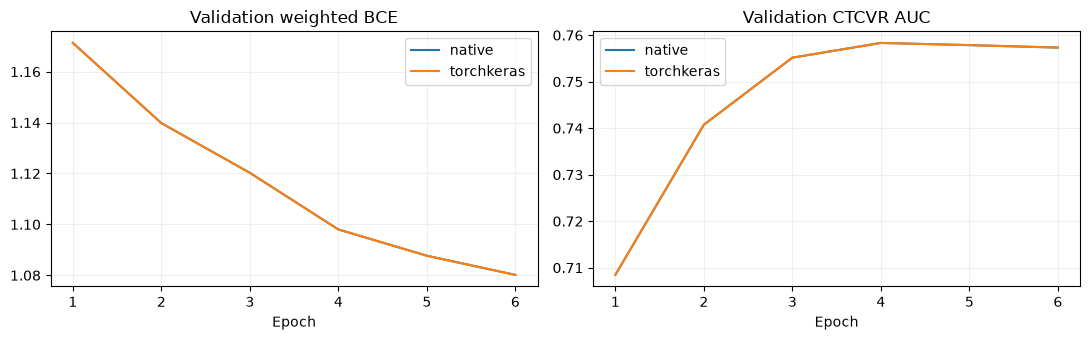

In [16]:
import matplotlib.pyplot as plt

display(
    space.compare(
        runs=[native_run.run_id, keras_run.run_id],
        metrics=["ctr_auc", "ctcvr_auc", "loss"],
        partitions=["valid", "test"],
        params=["optimizer.lr", "model.num_experts"],
        fields=["best_epoch"],
        metadata=["metadata.training_framework"],
    )
)
display(space.compare_params(native_run.run_id, keras_run.run_id))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for run in (native_run, keras_run):
    history = pd.DataFrame(run.read_json("history"))
    axes[0].plot(history.epoch, history.val_loss, label=run.name)
    axes[1].plot(history.epoch, history.val_ctcvr_auc, label=run.name)
for ax, title in zip(axes, ["Validation weighted BCE", "Validation CTCVR AUC"]):
    ax.set(title=title, xlabel="Epoch")
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 14. 改参：新配置、新 Run

先 deepcopy 再修改，在 start_run 前完成最终配置。不会改写 baseline 或已有 Run。

In [17]:
variant_cfg = deepcopy(cfg)
variant_cfg["optimizer"]["lr"] = cfg["optimizer"]["lr"] / 2
variant_cfg["model"]["num_experts"] = 6
variant_run = run_one(space, variant_cfg, partitions, state, "native", tensorboard=True)
display(space.compare_params(native_run.run_id, variant_run.run_id))
display(
    space.compare(
        runs=[native_run.run_id, keras_run.run_id, variant_run.run_id],
        metrics=["ctcvr_auc", "loss"],
        partitions=["valid", "test"],
        params=["optimizer.lr", "model.num_experts"],
    )
)

,parameter,esmm_mmoe_run_10,esmm_mmoe_run_12,change,left_present,right_present
0,model.num_experts,4,6,modified,True,True
1,optimizer.lr,0.001,0.0005,modified,True,True


,run,name,created_at,objective,metric,valid_ctcvr_auc,valid_loss,test_ctcvr_auc,test_loss,params
0,esmm_mmoe_run_10,native,2026-09-29T22:40:27.755084+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.757328,1.080155,0.771943,1.052599,"{'optimizer.lr': 0.001, 'model.num_experts': 4}"
1,esmm_mmoe_run_11,torchkeras,2026-09-29T22:40:28.020961+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.757328,1.080155,0.771943,1.052599,"{'optimizer.lr': 0.001, 'model.num_experts': 4}"
2,esmm_mmoe_run_12,native,2026-09-29T22:40:28.662969+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.733683,1.137271,0.723903,1.137341,"{'optimizer.lr': 0.0005, 'model.num_experts': 6}"


## 15. 可选 Hydra 配置派生

如需记录来源和 overrides，把 ConfigSource 本身传给 start_run，并用其 config 构造对象。
本例展示派生与 schema 解析，不额外启动第四次训练。

In [18]:
from phl_risk.modeling.experiment.adapters.hydra import compose_config

composed = compose_config(
    config_dir=space.config_dir,
    config_name="baseline",
    overrides=["optimizer.lr=0.0005", "loss.ctcvr_weight=2.0"],
)
composed.config["model"].update(
    num_continuous=len(continuous),
    categorical_cardinalities=[len(state["vocabularies"][c]) + 1 for c in categorical],
)
composed.config["data"].update(continuous_features=continuous, categorical_features=categorical)
print("Overrides:", composed.overrides)
display(composed.config["loss"])

Overrides: ('optimizer.lr=0.0005', 'loss.ctcvr_weight=2.0')


{'ctr_weight': 1.0, 'ctcvr_weight': 2.0}

## 16. 恢复推理、未知类别与条件 CVR

创建新的模型和预处理对象，使用校验过的 artifact。新数据仍使用旧词表，未知类别映射到 0。
CVR 的评估只针对第一阶段事件已发生的样本，不与 CTCVR 的全空间评估混淆。

In [19]:
from sklearn.metrics import roc_auc_score

saved = space.get_run(keras_run.run_id)
restored = load_pytorch(saved, ESMMMoE(**saved.read_json("model_config"))).eval()
saved_state = joblib.load(saved.artifact_path("preprocessor"))
predictions = predict_frame(restored, partitions["test"], saved_state)
display(predictions.head())
new_frame = partitions["test"].iloc[:5].copy()
new_frame["channel"] = "new-channel"
assert (transform_features(new_frame, saved_state)[0][:, 0] == 0).all()
display(predict_frame(restored, new_frame, saved_state))
clicked = partitions["test"].y_ctr.eq(1)
y_conditional = partitions["test"].loc[clicked, "y_ctcvr"]
if y_conditional.nunique() == 2:
    print("Conditional CVR AUC:", roc_auc_score(y_conditional, predictions.loc[clicked, "cvr"]))

,ctr,cvr,ctcvr
1986,0.382871,0.303129,0.116060
561,0.661683,0.383184,0.253546
1366,0.766722,0.547073,0.419453
1426,0.584379,0.291053,0.170085
869,0.663488,0.440134,0.292024


,ctr,cvr,ctcvr
1986,0.384057,0.301817,0.115915
561,0.466939,0.379795,0.177341
1366,0.768837,0.459760,0.353480
1426,0.489502,0.311203,0.152335
869,0.636007,0.370787,0.235823


Conditional CVR AUC: 0.7172675521821632


## 17. 标签异常与单类别指标

不能用假数值填补不存在的 AUC。evaluate_esmm 返回原因，Experiment 只记录有限数值。
下面的异常是预期的业务标签校验，不会中断 Notebook。

In [20]:
try:
    loss_fn(
        {"ctr": torch.tensor([[0.5]]), "ctcvr": torch.tensor([[0.2]])},
        {"ctr": torch.tensor([0.0]), "ctcvr": torch.tensor([1.0])},
    )
except ValueError as error:
    print("预期标签错误:", error)
else:
    raise AssertionError("Invalid chain was accepted")
all_negative = TensorDataset(
    torch.empty(5, 0, dtype=torch.long), torch.zeros(5, 2), torch.zeros(5), torch.zeros(5)
)
scores, undefined = evaluate_esmm(
    ESMMMoE(num_continuous=2), DataLoader(all_negative, batch_size=3), ESMMLoss()
)
assert "ctr_auc" not in scores
print("可记录的指标:", scores)
print("未定义指标原因:", undefined)

预期标签错误: Conversion chain requires y_ctcvr <= y_ctr
可记录的指标: {'loss': 1.0069279670715332, 'ctr_loss': 0.7107717990875244, 'ctcvr_loss': 0.2961561381816864}
未定义指标原因: {'ctr_auc': 'Only one target class is present', 'ctcvr_auc': 'Only one target class is present'}


## 18. 查看 TensorBoard 与迁移真实数据

仓库终端执行：
```bash
uv run --extra tensorboard tensorboard --logdir experiments/esmm_mmoe_notebook
```
每个 Run 的 tensorboard 目录独立，关闭 writer 后另有 `tensorboard.zip` 校验归档。

替换真实数据时：明确观察窗口和链路标签 → 选择时间/业务切分 → 只在 train 拟合预处理 →
从 schema 确定维数 → 用 valid 选模 → test 最终评估 → 保存和重载对照。

当前交付支持单进程，验证 CPU/float32；精确 AUC 需要 O(N) 预测存储。
完整断点续训还需 optimizer/scheduler/RNG/sampler 状态，不等同于加载权重。
设备、分布式、混合精度和采样策略变化应另外验证。

In [21]:
for run in (native_run, keras_run, variant_run):
    run.verify_artifacts()
    assert run.status == "completed"
    print(run.name, run.run_id, "artifacts:", list(run.artifacts))
print("三次实验的 artifact 校验完成。")

native esmm_mmoe_run_10_2026_09_29_224027 artifacts: ['config', 'overrides', 'undefined_metrics', 'history', 'model_config', 'model', 'preprocessor', 'tensorboard']
torchkeras esmm_mmoe_run_11_2026_09_29_224028 artifacts: ['config', 'overrides', 'undefined_metrics', 'history', 'model_config', 'model', 'preprocessor', 'tensorboard']
native esmm_mmoe_run_12_2026_09_29_224028 artifacts: ['config', 'overrides', 'undefined_metrics', 'history', 'model_config', 'model', 'preprocessor', 'tensorboard']
三次实验的 artifact 校验完成。


## Linux CPU / NVIDIA CUDA

本 Notebook 保存的是 Mac CPU 实测结果。两个脚本入口均支持 `--device cpu|cuda`，
Python 函数 `run_guide` / `run_large_guide` 可传 `device="cuda"`。
CUDA 不可用会提前报错；切换设备需重启内核，避免 Accelerate 的全局状态影响。
大数据示例默认 `num_workers=0`，单进程单 GPU、float32。

Linux 安装、CPU/CUDA 分别启动、实际 GPU 验收命令与范围见
[完整指南第 19 节](esmm_mmoe_complete_guide.md#19-linux-cpu-与-nvidia-cuda-部署)。
Ubuntu CI 已配置；尚未在 Linux 或 NVIDIA GPU 上实际验收。
